Dataset: yakhyokhuja/ms1m-arcface-dataset

In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
import insightface
from prettytable import PrettyTable
import random
import pickle
random.seed(42)

In [2]:
TRAIN_DATASET_PATH = "F:\code_datasets\datasets\ms1m-arcface"

note images are 112x112

In [3]:
file_paths = {}
for item in os.listdir(TRAIN_DATASET_PATH):
    file_paths[item] = os.listdir(os.path.join(TRAIN_DATASET_PATH, item))
identity_sample_length = [len(samples) for samples in file_paths.values()]

(array([2.3644e+04, 2.4742e+04, 3.1762e+04, 4.6100e+03, 2.4100e+02,
        2.1000e+02, 1.4500e+02, 1.1400e+02, 8.2000e+01, 7.8000e+01,
        4.8000e+01, 2.9000e+01, 1.7000e+01, 1.4000e+01, 3.0000e+00,
        3.0000e+00]),
 array([  2. ,  39.5,  77. , 114.5, 152. , 189.5, 227. , 264.5, 302. ,
        339.5, 377. , 414.5, 452. , 489.5, 527. , 564.5, 602. ]),
 <BarContainer object of 16 artists>)

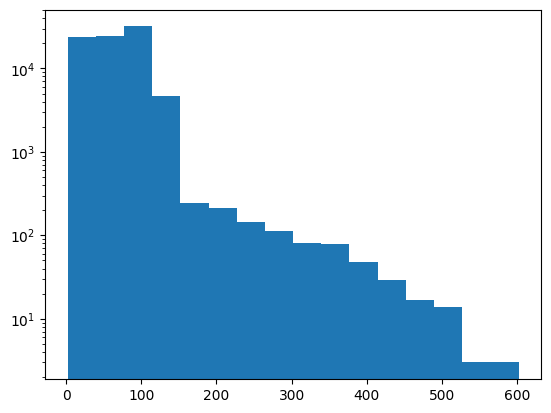

In [4]:
plt.hist(identity_sample_length, log=True, bins=16)

(array([ 7471., 10597., 10368.,  9419.,  9858., 11290., 13148., 10229.,
         2231.,   134.]),
 array([  2. ,  16.7,  31.4,  46.1,  60.8,  75.5,  90.2, 104.9, 119.6,
        134.3, 149. ]),
 <BarContainer object of 10 artists>)

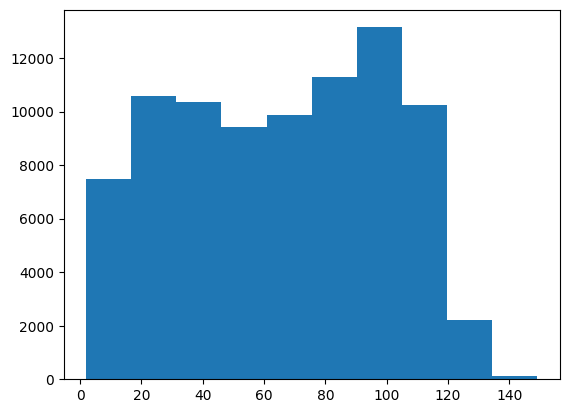

In [5]:
plt.hist([x for x in identity_sample_length if x < 150])

subsets for statistical analysis

In [73]:
subset_1, subset_2, subset_3 = [], [], []
for idx, (key, value) in enumerate(file_paths.items()):
    if random.random() < 0.1:
        for file_name in value:
            file_path = os.path.join(TRAIN_DATASET_PATH, key, file_name)
            value = random.random()
            if value > 0.9:
                subset_1.append(file_path)
            elif value < 0.1:
                subset_2.append(file_path)
            elif random.random() > 0.875:
                subset_3.append(file_path)
print(len(subset_1))
print(len(subset_2))
print(len(subset_3))



58647
58331
58913


face_detection_yunet_2023mar_int8bq
slow

check face size, angle

In [23]:
def get_angle(point_1, point_2) -> float:
    return np.degrees(np.atan((point_1[1] - point_2[1])/(point_1[0] - point_2[0])))

### Size Ratio ###
+---------+---------+--------+---------+------+----------+
| Minimum | Maximum | Median | Average | std  | outliers |
+---------+---------+--------+---------+------+----------+
|   0.09  |   1.0   |  0.64  |   0.65  | 0.07 |   0.0    |
|   0.08  |   1.0   |  0.64  |   0.65  | 0.07 |   0.0    |
|   0.03  |   1.0   |  0.64  |   0.65  | 0.07 |  2e-05   |
+---------+---------+--------+---------+------+----------+
### Roll ###
+---------+---------+--------+---------+------+----------+
| Minimum | Maximum | Median | Average | std  | outliers |
+---------+---------+--------+---------+------+----------+
|  -14.25 |  23.33  | -0.31  |  -0.39  | 1.22 |   0.0    |
|  -13.67 |  22.06  |  -0.3  |  -0.38  | 1.22 |   0.0    |
|  -12.48 |  15.76  | -0.31  |  -0.39  | 1.21 |   0.0    |
+---------+---------+--------+---------+------+----------+


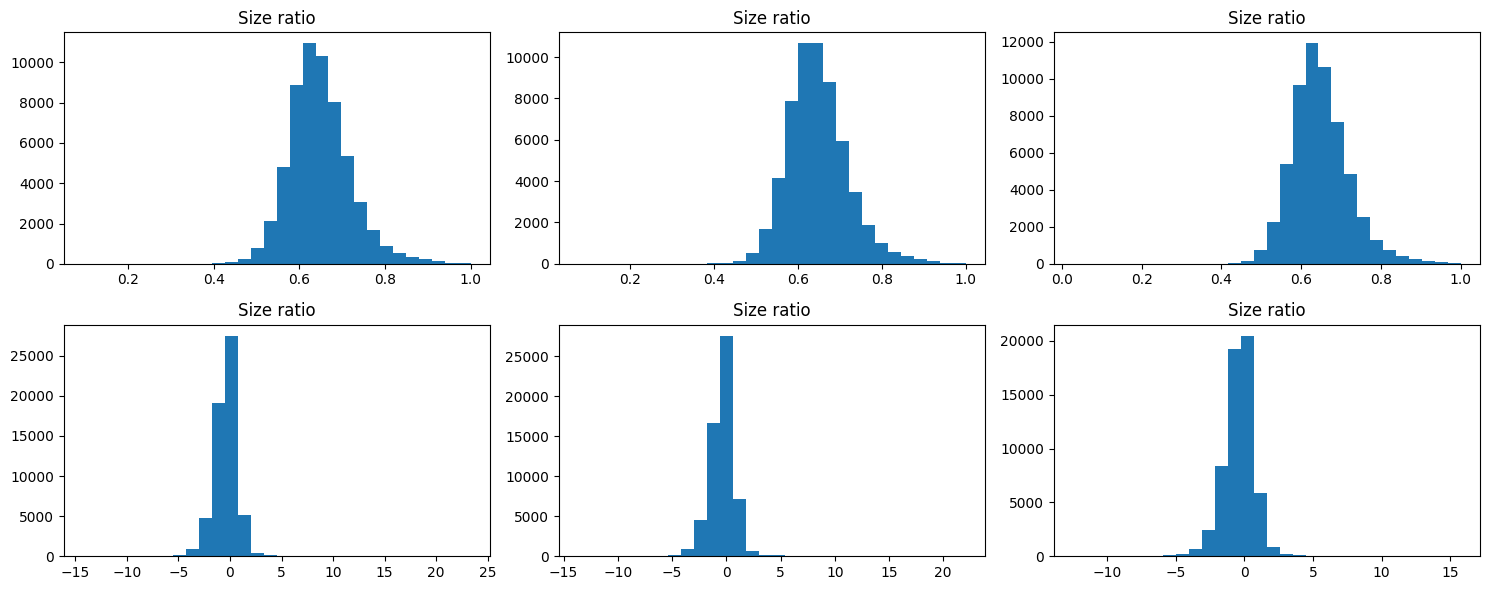

In [ ]:
def check_roll_size(subsets):
    _, axes = plt.subplots(2, len(subsets), figsize=(15, 6))
    table_size = PrettyTable()
    table_size.field_names = ["Minimum", "Maximum", "Median", "Average", "std", "outliers"]
    table_roll = PrettyTable()
    table_roll.field_names = ["Minimum", "Maximum", "Median", "Average", "std", "outliers"]
    for idx, subset in enumerate(subsets):
        sizes=[]
        roll=[]
        model_path = "face_detection_yunet_2023mar_int8bq.onnx"
        sample = cv2.imread(os.path.join(TRAIN_DATASET_PATH, '0', file_paths['0'][0]), cv2.IMREAD_COLOR)
        sample_height, sample_width = np.shape(sample)[:2]
        detector = cv2.FaceDetectorYN.create(model_path, "", (sample_height, sample_width), 0.6, 1)
        for file_path in subset:
            sample = cv2.imread(file_path, cv2.IMREAD_COLOR)
            output = detector.detect(sample)
            if output[1] is not None:
                single_output = output[1][0]
                face_width = single_output[2]
                face_height = single_output[3]
                left_eye = single_output[4:6]
                right_eye = single_output[6:8]
                size_ratio_clipped = min(((face_width * face_height) / np.multiply(sample_width, sample_height), 1.0))
                sizes.append(size_ratio_clipped)
                roll.append(get_angle(right_eye, left_eye))
        axes[0, idx].hist(sizes, bins=30)
        axes[0, idx].set_title("Size ratio")
        axes[1, idx].hist(roll, bins=30)
        axes[1, idx].set_title("Roll")
        table_size.add_row([
            round(min(sizes), 2),
            round(max(sizes), 2),
            round(np.median(sizes), 2),
            round(np.average(sizes), 2),
            round(np.std(sizes), 2),
            round(sum([1 for size in sizes if size < 0.05]) / len(sizes), 5)
        ])
        table_roll.add_row([
            round(min(roll), 2),
            round(max(roll), 2),
            round(np.median(roll), 2),
            round(np.average(roll), 2),
            round(np.std(roll), 2),
            round(sum([1 for x in roll if np.abs(x) > 30]) / len(roll), 5)
        ])
    print("### Size Ratio ###")
    print(table_size)
    print("### Roll ###")
    print(table_roll)
    plt.tight_layout()
    plt.show()
check_roll_size([subset_1, subset_2, subset_3])

retinaface slower

In [ ]:
# sizes={}
# roll={}
# model = insightface.app.FaceAnalysis(name="buffalo_sc")
# model.prepare(ctx_id=0, det_size=(128, 128)) #optymalny rozmiar skalowania dla retinaface 640x640, check
# for idx, (key, value) in enumerate(file_paths.items()):
#     sizes[key] = []
#     roll[key] = []
#     for file_name in value:
#         file_path = os.path.join(TRAIN_DATASET_PATH, key, file_name)
#         sample = cv2.imread(file_path, cv2.IMREAD_COLOR)
#         sample_height, sample_width = np.shape(sample)[:2]
#         output = model.get(sample)
#         if len(output) > 0:
#             single_output = output[0]
#             face_width = single_output['bbox'][2] - single_output['bbox'][0]
#             face_height = single_output['bbox'][3] - single_output['bbox'][1]
#             left_eye = single_output['kps'][1]
#             right_eye = single_output['kps'][0]
#             nose = single_output['kps'][2]
#             left_mouth = single_output['kps'][3]
#             right_mouth = single_output['kps'][4]
#             sizes[key].append((face_width * face_height) / np.multiply(sample_width, sample_height))
#             roll[key].append(get_angle(right_eye, left_eye))
#         else:
#             print("failed")
#     print(f"Running: {idx / len(file_paths.items()):.2f}")

Blur detection

### Blur ###
+---------+---------+--------+---------+-----+----------+
| Minimum | Maximum | Median | Average | std | outliers |
+---------+---------+--------+---------+-----+----------+
|   5.0   |  45067  |  344   |   485   | 616 |   0.01   |
|   5.96  |  39984  |  342   |   485   | 605 |  0.011   |
|   5.83  |  33395  |  345   |   481   | 521 |  0.011   |
+---------+---------+--------+---------+-----+----------+


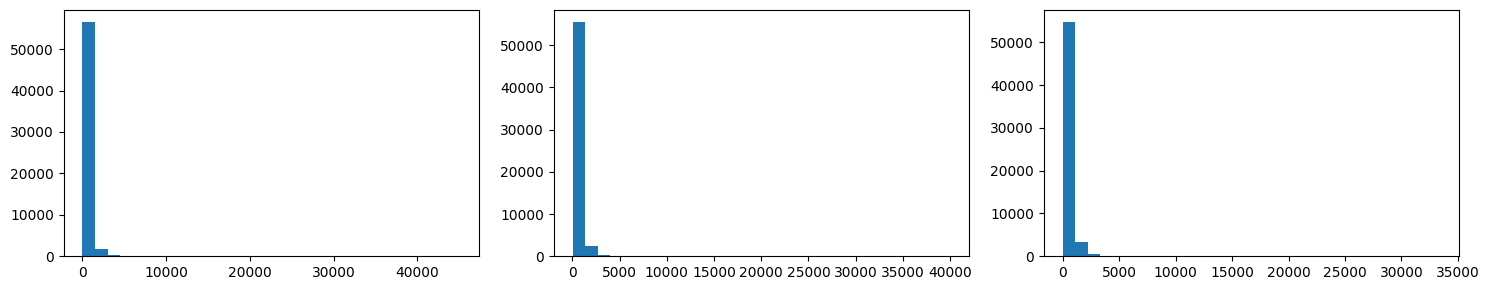

In [101]:
def check_blur(subsets):
    _, axes = plt.subplots(1, len(subsets), figsize=(15,3))
    table = PrettyTable()
    table.field_names = ["Minimum", "Maximum", "Median", "Average", "std", "outliers"]
    for idx, subset in enumerate(subsets):
        blur=[]
        for file_path in subset:
            sample = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            blur.append(cv2.Laplacian(sample, cv2.CV_64F).var())
        table.add_row([
            round(min(blur), 2),
            round(max(blur)),
            round(np.median(blur)),
            round(np.average(blur)),
            round(np.std(blur)),
            round(sum([1 for value in blur if value < 50]) / len(blur), 3)
        ])
        axes[idx].hist(blur, bins=30)
    print("### Blur ###")
    print(table)
    plt.tight_layout()
    plt.show()
check_blur([subset_1, subset_2, subset_3])

### Contrast ###
+---------+---------+--------+---------+-----+----------+
| Minimum | Maximum | Median | Average | std | outliers |
+---------+---------+--------+---------+-----+----------+
|    12   |   121   |   56   |    57   |  14 |  0.001   |
|    12   |   115   |   56   |    57   |  14 |  0.001   |
|    11   |   115   |   56   |    57   |  14 |  0.001   |
+---------+---------+--------+---------+-----+----------+
### Brightness ###
+---------+---------+--------+---------+-----+----------+
| Minimum | Maximum | Median | Average | std | outliers |
+---------+---------+--------+---------+-----+----------+
|    18   |   233   |  117   |   117   |  29 |  0.009   |
|    12   |   241   |  117   |   117   |  29 |  0.009   |
|    15   |   238   |  117   |   117   |  29 |  0.009   |
+---------+---------+--------+---------+-----+----------+


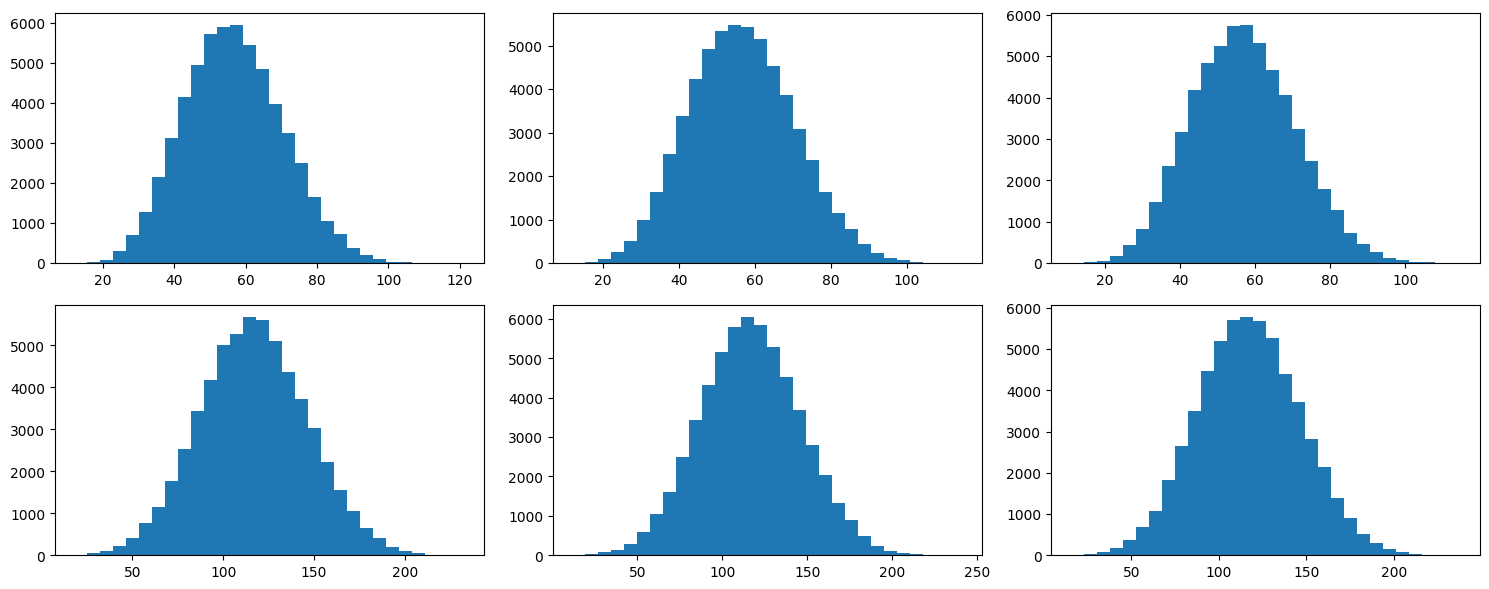

In [100]:
def check_brightness_contrast(subsets):
    _, axes = plt.subplots(2, len(subsets), figsize=(15,6))
    table_b = PrettyTable()
    table_b.field_names = ["Minimum", "Maximum", "Median", "Average", "std", "outliers"]
    table_c = PrettyTable()
    table_c.field_names = ["Minimum", "Maximum", "Median", "Average", "std", "outliers"]
    for idx, subset in enumerate(subsets):
        contrast=[]
        brightness=[]
        for file_path in subset:
            sample = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            contrast.append(np.std(sample))
            brightness.append(np.mean(sample))
        table_c.add_row([
            round(min(contrast)),
            round(max(contrast)),
            round(np.median(contrast)),
            round(np.average(contrast)),
            round(np.std(contrast)),
            round(sum([1 for value in contrast if value < 20]) / len(contrast), 3)
        ])
        table_b.add_row([
            round(min(brightness)),
            round(max(brightness)),
            round(np.median(brightness)),
            round(np.average(brightness)),
            round(np.std(brightness)),
            round(sum([1 for value in brightness if value < 50 or value > 220]) / len(brightness), 3)
        ])
        axes[0, idx].hist(contrast, bins=30)
        axes[1, idx].hist(brightness, bins=30)
    print("### Contrast ###")
    print(table_c)
    print("### Brightness ###")
    print(table_b)
    plt.tight_layout()
    plt.show()
check_brightness_contrast([subset_1, subset_2, subset_3])

embedding analysis

In [44]:
subset_embedding_analysis = {}
for idx, (key, value) in enumerate(file_paths.items()):
    if random.random() < 0.01:
        subset_embedding_analysis[key] = []
        for file_name in value:
            file_path = os.path.join(TRAIN_DATASET_PATH, key, file_name)
            subset_embedding_analysis[key].append(file_path)
print(len(subset_embedding_analysis))
print(len(np.concatenate(list(subset_embedding_analysis.values())).tolist()))

859
57665


In [45]:
embeddings={}
embeddings_norm={}
app = insightface.app.FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider'])
app.prepare(ctx_id=0, det_size=(128, 128))
for idx, (key, value) in enumerate(subset_embedding_analysis.items()):
    embeddings[key] = []
    embeddings_norm[key] = []
    for file_name in value:
        file_path = os.path.join(TRAIN_DATASET_PATH, key, file_name)
        sample = cv2.imread(file_path, cv2.IMREAD_COLOR)
        output = app.get(sample)
        if len(output) > 0:
            embeddings[key].append(output[0].embedding)
            embeddings_norm[key].append(output[0].normed_embedding)
        else:
            print("failed")
    print(f"Running: {(idx / len(subset_embedding_analysis.items()))*100:.2f}%", end='\r')

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Paweł B/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Paweł B/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Paweł B/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Paweł B/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Paweł B/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112,

f:\codes\projekty\face_verification\face_verification\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


failedg: 23.05%
failedg: 44.00%
failedg: 48.89%
failedg: 84.98%
failed
failed
failed


7 failed out of 57665

In [4]:
with open("../data/embeddings.pickle", "rb") as f:
    embeddings = pickle.load(f)
with open("../data/embeddings_norm.pickle", "rb") as f:
    embeddings_norm = pickle.load(f)


embedding norm distribiution

In [7]:
def flatten_dict(some_dict: dict[str, list]) -> list:
    return [value for value_list in some_dict.values() for value in value_list]

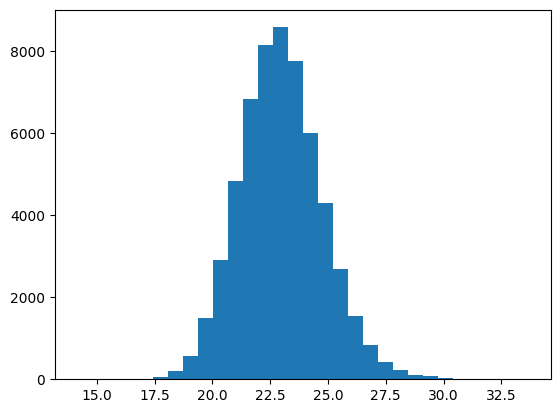

In [ ]:
def plot_embedding_norm_dist(embeddings): #(20-25 high quality)
    embeddings_list = flatten_dict(embeddings)
    norms = []
    for embedding in embeddings_list:
        norms.append(np.linalg.norm(embedding))
    plt.hist(norms, bins=30)
plot_embedding_norm_dist(embeddings)

embedding outliers

In [30]:
def compute_embedding_outliers(emb_list):
    emb_array = np.vstack(emb_list)
    centroid = emb_array.mean(axis=0)

    dists = np.linalg.norm(emb_array - centroid, axis=1)
    mean = dists.mean()
    std = dists.std()

    outliers = dists > (mean + 2 * std)
    return (outliers.sum() / len(emb_list))*100

def get_outliers(embeddings):
    entity_outliers = []
    table = PrettyTable()
    table.field_names = ["Minimum", "Maximum", "Median", "Average", "std"]
    for _, value in embeddings.items():
        entity_outliers.append(compute_embedding_outliers(value))
    table.add_row([
            round(min(entity_outliers), 5),
            round(max(entity_outliers), 3),
            round(np.median(entity_outliers), 3),
            round(np.average(entity_outliers), 3),
            round(np.std(entity_outliers), 3)
        ])
    print(table)
get_outliers(embeddings)

+---------+---------+--------+---------+-------+
| Minimum | Maximum | Median | Average |  std  |
+---------+---------+--------+---------+-------+
|   0.0   |  14.286 | 3.704  |  3.786  | 2.437 |
+---------+---------+--------+---------+-------+


intra class distances

In [ ]:
def get_intra_class_distances(embeddings_norm): # good 0,15
    distances = []
    table = PrettyTable()
    table.field_names = ["Minimum", "Maximum", "Median", "Average", "std"]
    for _, value in embeddings_norm.items():
        emb_array = np.vstack(value)
        cosine_sim = emb_array @ emb_array.T
        cosine_dist = 1 - cosine_sim
        mask = np.triu(np.ones((len(value), len(value))), k = 1).astype(bool)
        mean = cosine_dist[mask].mean()
        distances.append(mean)

    table.add_row([
            round(min(distances), 3),
            round(max(distances), 3),
            round(np.median(distances), 3),
            round(np.average(distances), 3),
            round(np.std(distances), 3)
        ])
    print(table)
get_intra_class_distances(embeddings_norm)

+---------+---------+--------+---------+-------+
| Minimum | Maximum | Median | Average |  std  |
+---------+---------+--------+---------+-------+
|  0.049  |  0.824  | 0.404  |  0.411  | 0.093 |
+---------+---------+--------+---------+-------+


inter class distances

In [50]:
def get_inter_class_distances(embeddings_norm, samples_per_class=20, max_pairs=50000):
    labeled_embs = []
    for label, embs in embeddings_norm.items():
        if len(embs) == 0:
            continue
        chosen = random.sample(embs, min(samples_per_class, len(embs)))
        for e in chosen:
            labeled_embs.append((label, e))

    distances = []
    attempts = 0
    while len(distances) < max_pairs and attempts < max_pairs * 5:
        a, b = random.sample(labeled_embs, 2)
        attempts += 1
        if a[0] == b[0]:
            continue

        sim = np.dot(a[1], b[1])
        dist = 1 - sim
        distances.append(dist)

    table = PrettyTable()
    table.field_names = ["Minimum", "Maximum", "Median", "Average", "std"]
    table.add_row([
        round(float(np.min(distances)), 3),
        round(float(np.max(distances)), 3),
        round(float(np.median(distances)), 3),
        round(float(np.mean(distances)), 3),
        round(float(np.std(distances)), 3),
    ])
    print(table)

get_inter_class_distances(embeddings_norm)

+---------+---------+--------+---------+-------+
| Minimum | Maximum | Median | Average |  std  |
+---------+---------+--------+---------+-------+
|  0.621  |  1.219  | 0.976  |  0.975  | 0.059 |
+---------+---------+--------+---------+-------+


t-sne / umap visualisation

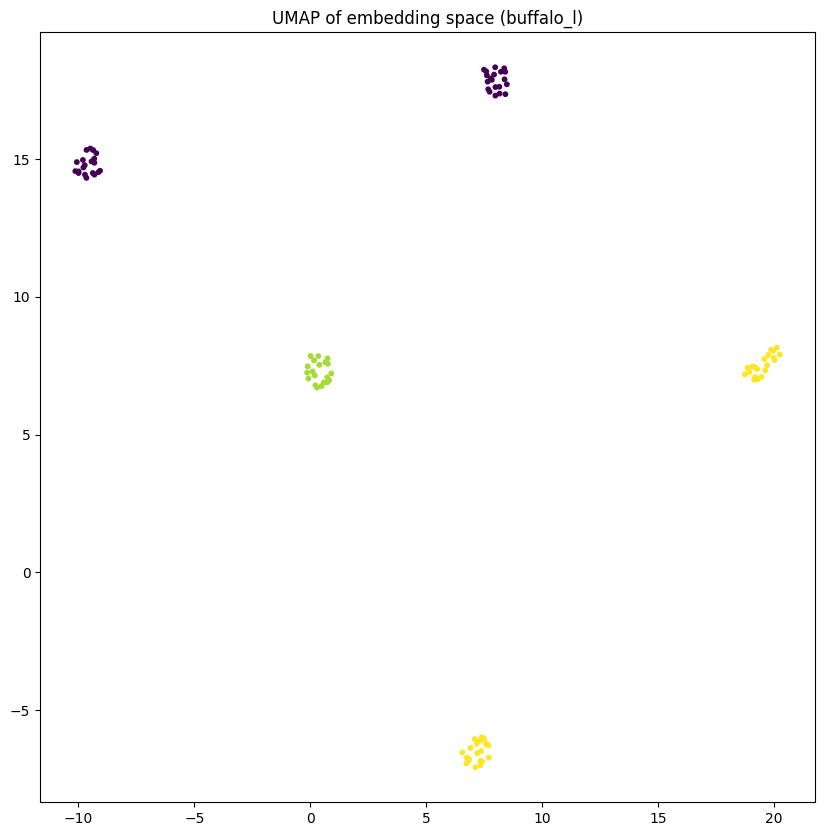

In [54]:
import umap.umap_ as umap
def visualise_sample(embeddings_norm, max_classes=5, samples_per_class=20):
    X = []
    y = []

    labels = list(embeddings_norm.keys())
    labels = labels[:max_classes]

    for label in labels:
        embs = embeddings_norm[label]
        chosen = random.sample(embs, min(samples_per_class, len(embs)))
        for e in chosen:
            X.append(e)
            y.append(label)

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
    X_2d = reducer.fit_transform(X)

    plt.figure(figsize=(10, 10))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=[hash(v) % 20 for v in y], s=10)
    plt.title("UMAP of embedding space (buffalo_l)")
    plt.show()

visualise_sample(embeddings_norm)

